In [1]:
!pip install -q kagglehub
!pip install pandas

In [2]:
import kagglehub


path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)

print("Path to dataset files:", path)

100%|██████████| 64.8k/64.8k [00:00<00:00, 12.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1


In [ ]:
import os

path = "/root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1"
print(os.listdir(path))


['tesla_deliveries_dataset_2015_2025.csv']


if path eror past the above path

In [ ]:
import pandas as pd
df = pd.read_csv(   "paste path you above got with / name of your csv file "
)


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [4]:
df.shape
df.head()

NameError: name 'df' is not defined

In [ ]:
df.isnull().values.any()


np.False_

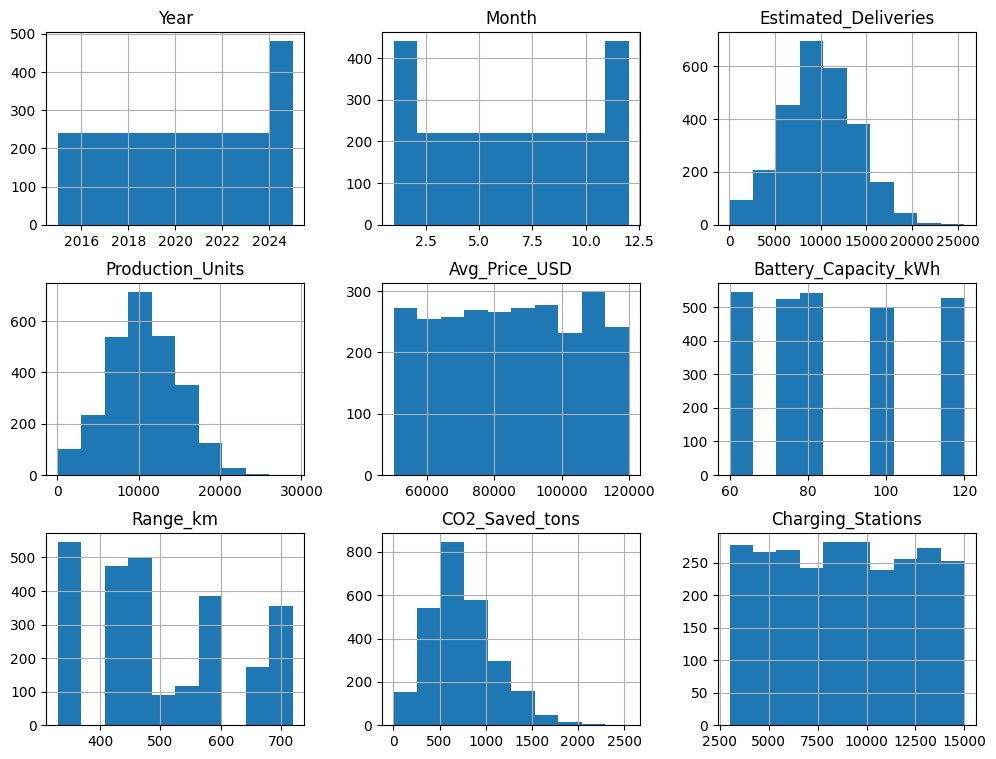

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,9))
plt.show()

In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [ ]:
#for sales
df["Estimated_Deliveries"].describe()

,Estimated_Deliveries
count,2640.000000
mean,9922.199621
std,3935.950093
min,48.000000
25%,7292.000000
50%,9857.000000
75%,12510.250000
max,25704.000000


In [ ]:
#for proce
df["Avg_Price_USD"].describe()

,Avg_Price_USD
count,2640.000000
mean,84907.340330
std,20123.258036
min,50003.700000
25%,67726.365000
50%,85058.510000
75%,102373.042500
max,119965.360000


<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

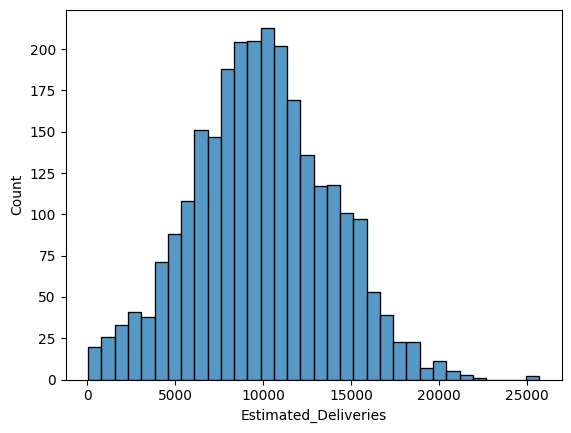

In [ ]:
sns.histplot(df["Estimated_Deliveries"])

<Axes: >

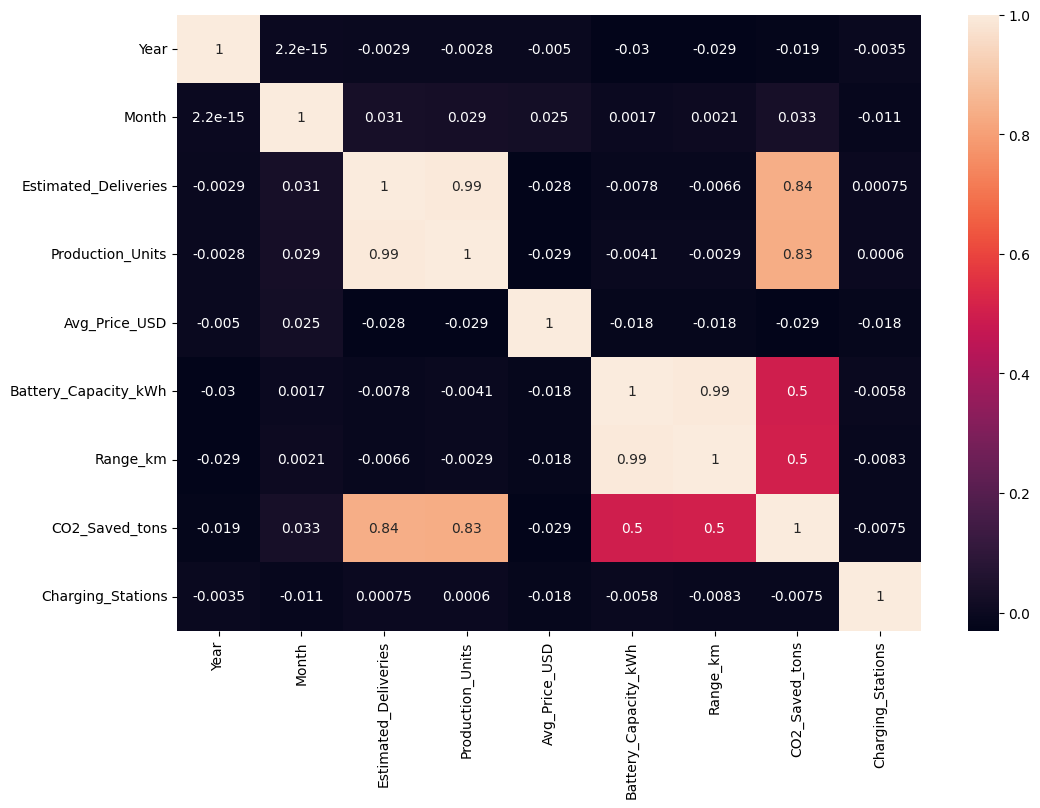

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True
)

In [ ]:
corr["Estimated_Deliveries"]\
.sort_values(ascending=False)

,Estimated_Deliveries
Estimated_Deliveries,1.000000
Production_Units,0.994234
CO2_Saved_tons,0.836814
Month,0.030877
Charging_Stations,0.000753
Year,-0.002863
Range_km,-0.006606
Battery_Capacity_kWh,-0.007765
Avg_Price_USD,-0.027546


In [ ]:
df["Estimated_Deliveries"].describe()

,Estimated_Deliveries
count,2640.000000
mean,9922.199621
std,3935.950093
min,48.000000
25%,7292.000000
50%,9857.000000
75%,12510.250000
max,25704.000000


In [ ]:
df["Estimated_Deliveries"].describe()

df["Avg_Price_USD"].describe()

,Avg_Price_USD
count,2640.000000
mean,84907.340330
std,20123.258036
min,50003.700000
25%,67726.365000
50%,85058.510000
75%,102373.042500
max,119965.360000


In [ ]:
df.groupby("Model")[
    "Avg_Price_USD"
].mean().sort_values()

,Avg_Price_USD
Model,
Model X,84243.212936
Cybertruck,84498.872159
Model 3,84528.004223
Model S,85185.401269
Model Y,86081.211061


In [ ]:
df.groupby("Model")[
    "Estimated_Deliveries"
].mean().sort_values()

,Estimated_Deliveries
Model,
Cybertruck,9677.611742
Model X,9767.500000
Model Y,9896.371212
Model 3,10079.392045
Model S,10190.123106


In [ ]:
corr["Avg_Price_USD"].sort_values(ascending=False)

,Avg_Price_USD
Avg_Price_USD,1.000000
Month,0.024857
Year,-0.004991
Charging_Stations,-0.017790
Range_km,-0.017854
Battery_Capacity_kWh,-0.018203
Estimated_Deliveries,-0.027546
CO2_Saved_tons,-0.028523
Production_Units,-0.029263


In [ ]:
df[[
"Avg_Price_USD",
"Battery_Capacity_kWh",
"Range_km"
]].corr()

,Avg_Price_USD,Battery_Capacity_kWh,Range_km
Avg_Price_USD,1.000000,-0.018203,-0.017854
Battery_Capacity_kWh,-0.018203,1.000000,0.994313
Range_km,-0.017854,0.994313,1.000000


In [ ]:
df.groupby("Region")["Avg_Price_USD"].mean()

,Avg_Price_USD
Region,
Asia,85161.733773
Europe,86107.731939
Middle East,84535.999091
North America,83823.896515


In [ ]:
df.groupby("Source_Type")["Avg_Price_USD"].mean()

,Avg_Price_USD
Source_Type,
Estimated (Region),84609.806938
Interpolated (Month),84815.098428
Official (Quarter),85293.076708


In [ ]:
df.groupby(["Region","Model"])["Avg_Price_USD"].mean()

Region         Model     
Asia           Cybertruck    84147.057424
               Model 3       83648.832348
               Model S       89114.632576
               Model X       83070.505379
               Model Y       85827.641136
Europe         Cybertruck    85447.803561
               Model 3       87677.108485
               Model S       84344.240758
               Model X       85843.229697
               Model Y       87226.277197
Middle East    Cybertruck    84378.702348
               Model 3       81916.669470
               Model S       85189.275303
               Model X       84242.461894
               Model Y       86952.886439
North America  Cybertruck    84021.925303
               Model 3       84869.406591
               Model S       82093.456439
               Model X       83816.654773
               Model Y       84318.039470
Name: Avg_Price_USD, dtype: float64

In [ ]:
num_cols = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

In [ ]:

cat_cols = [
    "Region",
    "Model",
    "Source_Type"
]

In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [ ]:
sales_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [ ]:
X = df.drop(columns=["Estimated_Deliveries"])

y = df["Estimated_Deliveries"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
sales_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [ ]:
predictions = sales_pipeline.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 309.70777855911626
RMSE: 385.8405421084591
R2  : 0.9906683310047931


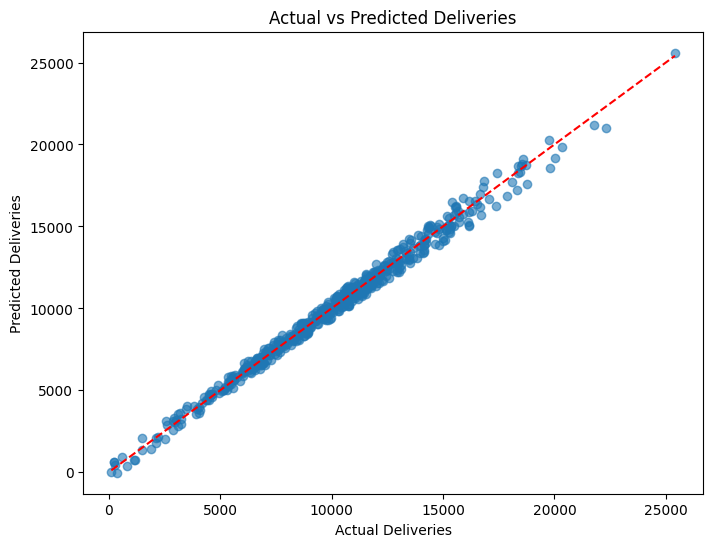

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

now for estimated price

In [ ]:
num_cols = [

    "Year",
    "Month",

    "Estimated_Deliveries",

    "Production_Units",

    "Battery_Capacity_kWh",

    #"Range_km",

    "CO2_Saved_tons",

    "Charging_Stations"

]


In [ ]:
cat_cols = [
    "Region",
    "Model",
    "Source_Type"
]


In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])



In [ ]:
cat_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )

])

In [ ]:





preprocessor = ColumnTransformer([

    (
        "num",
        num_pipeline,
        num_cols
    ),

    (
        "cat",
        cat_pipeline,
        cat_cols
    )

])

In [ ]:
price_pipeline = Pipeline([

    (
        "preprocessing",
        preprocessor
    ),

    (
        "model",
        LinearRegression()
    )

])

In [ ]:
X = df.drop(columns=["Avg_Price_USD"])

y = df["Avg_Price_USD"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [ ]:
price_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Estimated_Deliveries',
                                                   'Production_Units',
                                                   'Battery_Capacity_kWh',
                                                   'CO2_Saved_tons',
                                                   'Charging_Stations']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [ ]:
price_preds = price_pipeline.predict(
    X_test
)

In [ ]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 75992.09596444183
RMSE: 78598.51290731368
R2  : -14.830327458529748


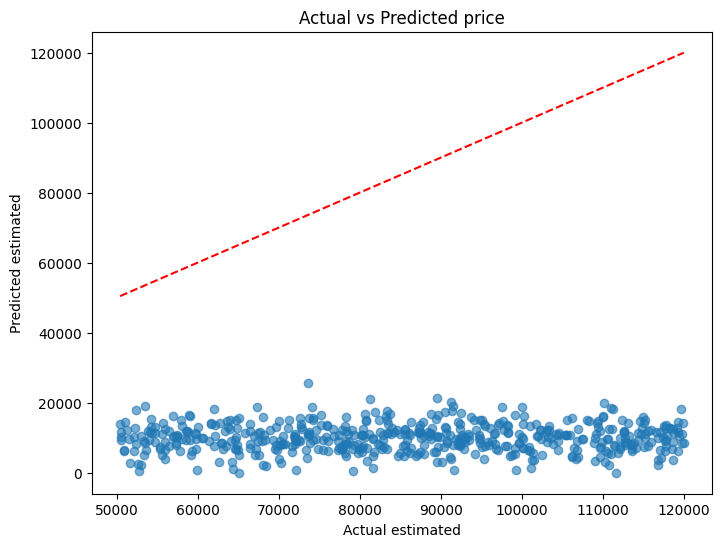

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual estimated")
plt.ylabel("Predicted estimated")
plt.title("Actual vs Predicted price")

plt.show()